In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats

In [8]:
# reference: https://online.stat.psu.edu/stat462/node/101/
df = pd.read_csv('../datasets/teen_birth_rate_and_poverty_level.txt', sep='\t') 
df.head()

,Location,PovPct,Brth15to17,Brth18to19,ViolCrime,TeenBrth
0,Alabama,20.1,31.5,88.7,11.2,54.5
1,Alaska,7.1,18.9,73.7,9.1,39.5
2,Arizona,16.1,35.0,102.5,10.4,61.2
3,Arkansas,14.9,31.6,101.7,10.4,59.9
4,California,16.7,22.6,69.1,11.2,41.1


In [32]:
df[['PovPct', 'Brth15to17', 'Brth18to19', 'ViolCrime', 'TeenBrth']].corr()

,PovPct,Brth15to17,Brth18to19,ViolCrime,TeenBrth
PovPct,1.000000,0.730293,0.649660,0.469564,0.703285
Brth15to17,0.730293,1.000000,0.942449,0.640274,0.978826
Brth18to19,0.649660,0.942449,1.000000,0.477704,0.988975
ViolCrime,0.469564,0.640274,0.477704,1.000000,0.557937
TeenBrth,0.703285,0.978826,0.988975,0.557937,1.000000


In [60]:
# data split
X=df[['PovPct']]
y=df['Brth15to17']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = LinearRegression()
model.fit(X_train, y_train)
slope = model.coef_[0]
intercept = model.intercept_

# model on total data (just for test! the same result as above link)
model_ = LinearRegression()
model_.fit(X, y)
slope_ = model_.coef_[0]
intercept_ = model_.intercept_

# predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# equation
print("\n" + "="*50)
print("SIMPLE LINEAR REGRESSION: Poverty vs Brth15to17")
print("="*50)
print(f"\nEquation: Brth15to17 = {intercept:.2f} + {slope:.2f} × PovPct")
print(f"Equation (same as link): Brth15to17 = {intercept_:.3f} + {slope_:.3f} × PovPct")

# performance metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print(f"Model Performance:")
print("="*50)
print(f"Training R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")
print(f"The value of r2 can be interpreted to mean that poverty rates explain {r2_test:0.2%} of the observed variation\n in the 15 to 17 year old average birth rates of the states.")
if abs(r2_train - r2_test) < 0.05:
    print("✅ Good: Training and testing R² are similar - no overfitting")
else:
    print(f"⚠️  Warning: Difference of {abs(r2_train - r2_test):.3f} between training and testing R²")

print()

print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")

print()

print(f"\n📊 RMSE (Root Mean Squared Error):")
print(f"   Training: {rmse_train:.2f} teen births per 1000")
print(f"   Testing: {rmse_test:.2f} teen births per 1000")
print(f"   → On average, predictions are off by ±{rmse_test:.1f} teen births per 1000")
print(f"   → This is about {rmse_test/df['TeenBrth'].mean()*100:.1f}% of the mean teen birth rate")
if rmse_test < df['TeenBrth'].std():
    print(f"✅ Good: RMSE ({rmse_test:.2f}) < Standard Deviation ({df['TeenBrth'].std():.2f})")
else:
    print(f"⚠️  RMSE exceeds standard deviation")
    
print()

print(f"Training MAE: {mae_train:.2f}")
print(f"Test MAE: {mae_test:.2f}")


SIMPLE LINEAR REGRESSION: Poverty vs Brth15to17

Equation: Brth15to17 = 4.02 + 1.39 × PovPct
Equation (same as link): Brth15to17 = 4.267 + 1.373 × PovPct

Model Performance:
Training R²: 0.4543
Test R²: 0.5974
The value of r2 can be interpreted to mean that poverty rates explain 59.74% of the observed variation
 in the 15 to 17 year old average birth rates of the states.
⚠️  Warning: Difference of 0.143 between training and testing R²

Training MSE: 29.61
Test MSE: 29.59


📊 RMSE (Root Mean Squared Error):
   Training: 5.44 teen births per 1000
   Testing: 5.44 teen births per 1000
   → On average, predictions are off by ±5.4 teen births per 1000
   → This is about 12.9% of the mean teen birth rate
✅ Good: RMSE (5.44) < Standard Deviation (12.32)

Training MAE: 4.52
Test MAE: 3.98


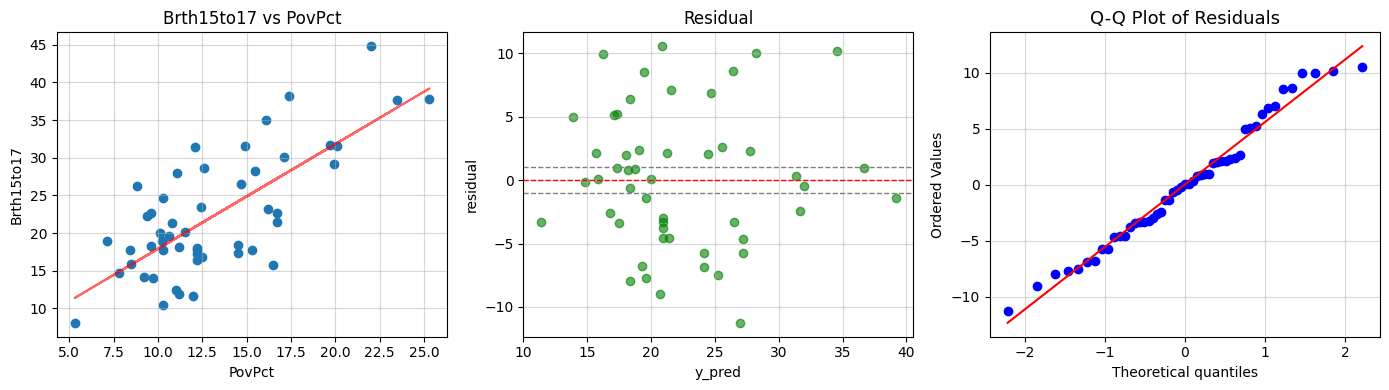

In [53]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(x=X, y=y)
plt.plot(X, model.predict(X), color='red', alpha=0.6)
plt.xlabel('PovPct')
plt.ylabel('Brth15to17')
plt.title('Brth15to17 vs PovPct')
plt.grid(alpha=0.5)

plt.subplot(1, 3, 2)
y_pred = model.predict(X)
residuals = y - y_pred
plt.scatter(y_pred, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1)
plt.xlabel('y_pred')
plt.ylabel('residual')
plt.title('Residual')
plt.grid(alpha=0.5)

plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals', fontsize=13)
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [63]:
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
if r2_test > 0.7 and mape_test < 15:
    print("\n✅ Overall Model Quality: GOOD")
    print("   • Strong relationship established")
    print("   • Reasonable prediction accuracy")
    print("   • Useful for policy analysis")
elif r2_test > 0.5 and mape_test < 25:
    print("\n⚠️  Overall Model Quality: MODERATE")
    print("   • Relationship is present but not perfect")
    print("   • Useful for understanding trends")
    print("   • Consider adding more variables")
else:
    print("\n❌ Overall Model Quality: NEEDS IMPROVEMENT")
    print("   • Consider adding more variables")
    print("   • Check for outliers")
    print("   • Try non-linear models")


⚠️  Overall Model Quality: MODERATE
   • Relationship is present but not perfect
   • Useful for understanding trends
   • Consider adding more variables
